In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Superstore.csv', encoding='ISO-8859-1')

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(9994, 21)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

In [ ]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,2015


In [ ]:
# KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()
avg_discount = df['Discount'].mean()

In [ ]:
print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders}")
print(f"Avg Discount: {avg_discount:.2%}")

Total Sales: 2,297,200.86
Total Profit: 286,397.02
Profit Margin: 12.47%
Total Orders: 5009
Avg Discount: 15.62%


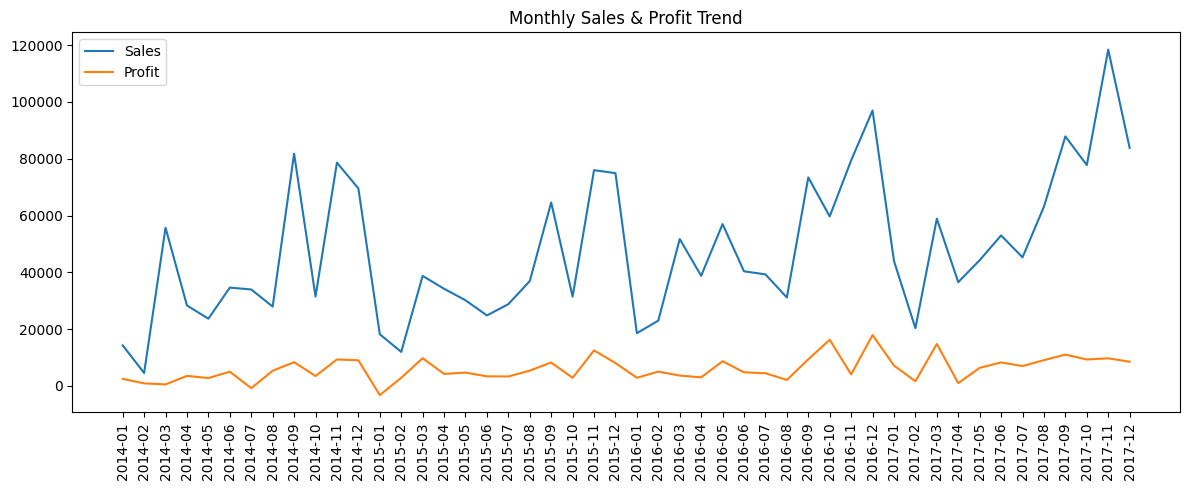

In [32]:
# SALES & PROFIT TREND OVER TIME
monthly = df.groupby('Order Month')[['Sales', 'Profit']].sum().reset_index()
monthly['Order Month'] = monthly['Order Month'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly['Order Month'], monthly['Sales'], label='Sales')
plt.plot(monthly['Order Month'], monthly['Profit'], label='Profit')
plt.xticks(rotation=90)
plt.title('Monthly Sales & Profit Trend')
plt.legend()
plt.tight_layout()
plt.savefig('sales_profit_trend.png')
plt.show()


/tmp/ipykernel_4796/2126404666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sales['Profit'], y=subcat_sales.index, palette='coolwarm')


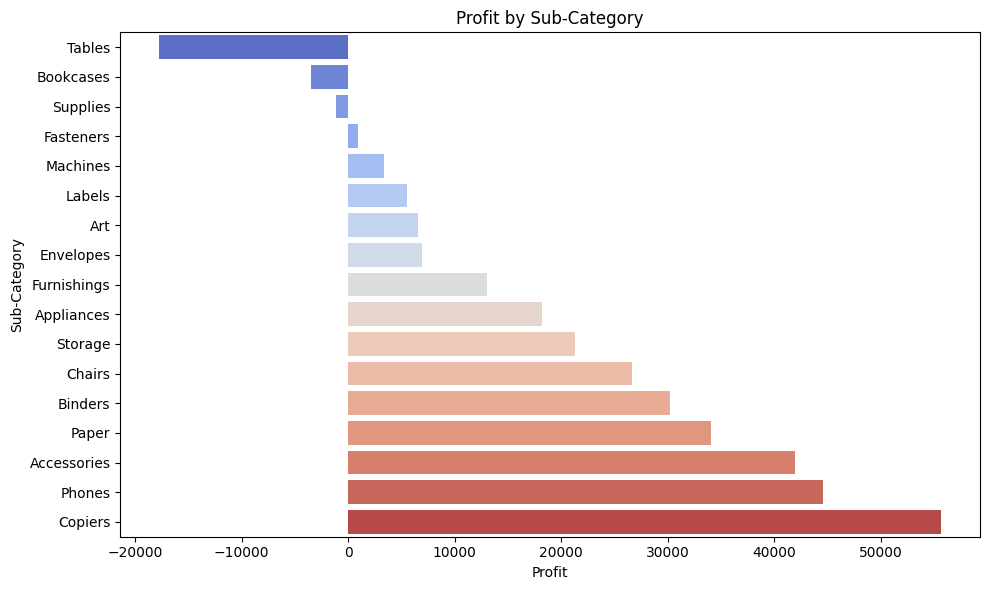

In [21]:
# SALES BY CATEGORY
cat_sales = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
subcat_sales = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Profit')

plt.figure(figsize=(10,6))
sns.barplot(x=subcat_sales['Profit'], y=subcat_sales.index, palette='coolwarm')
plt.title('Profit by Sub-Category')
plt.tight_layout()
plt.savefig('profit_subcategory.png')
plt.show()


/tmp/ipykernel_4796/2870320293.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales['Sales'], y=state_sales.index, palette='viridis')


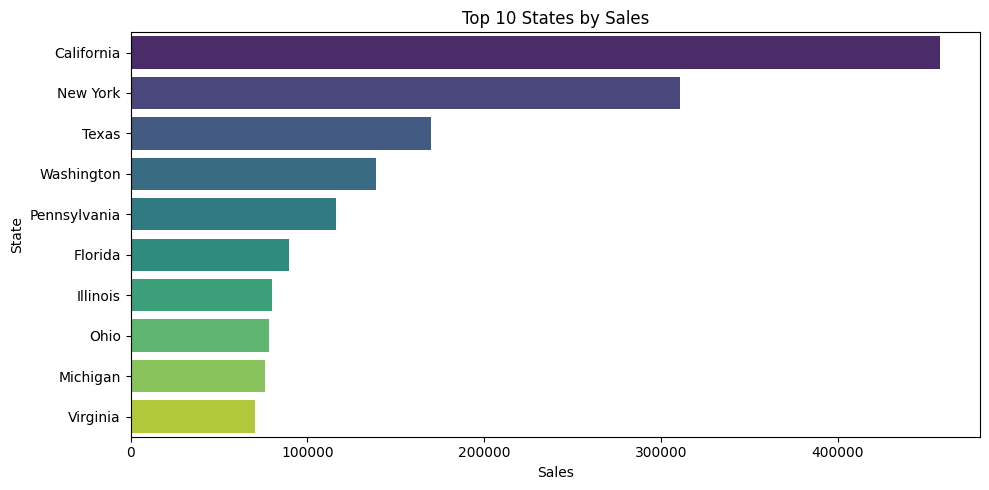

In [22]:
# SALES BY REGION
region_sales = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
state_sales = df.groupby('State')[['Sales','Profit']].sum().sort_values('Sales', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_sales['Sales'], y=state_sales.index, palette='viridis')
plt.title('Top 10 States by Sales')
plt.tight_layout()
plt.savefig('top_states_sales.png')
plt.show()

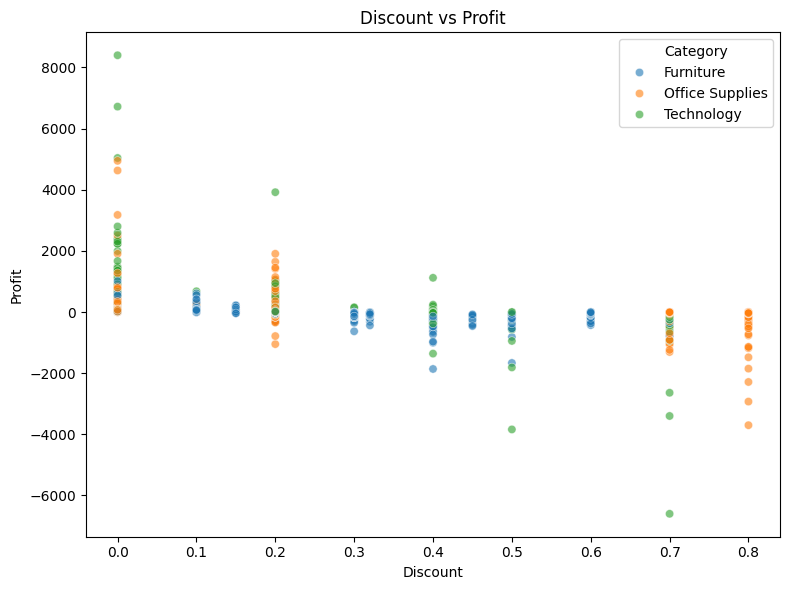

Discount
(-0.01, 0.0]     66.900292
(0.0, 0.1]       96.055074
(0.1, 0.2]       24.738824
(0.2, 0.3]      -45.679636
(0.3, 0.5]     -156.282991
(0.5, 1.0]      -89.438144
Name: Profit, dtype: float64


/tmp/ipykernel_4796/1143060184.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby(discount_bins)['Profit'].mean()


In [23]:
# DISCOUNT VS PROFIT
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit')
plt.tight_layout()
plt.savefig('discount_vs_profit.png')
plt.show()

discount_bins = pd.cut(df['Discount'], bins=[-0.01,0,0.1,0.2,0.3,0.5,1])
discount_profit = df.groupby(discount_bins)['Profit'].mean()
print(discount_profit)

In [28]:
# TOP CUSTOMERS & PRODUCTS
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

print(top_customers)
print()
print(top_products)
print()
print("Biggest loss-making products:\n", loss_products)


Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
H

In [29]:
# SEGMENT ANALYSIS
segment_perf = df.groupby('Segment')[['Sales','Profit','Quantity']].sum()
print(segment_perf)

                    Sales       Profit  Quantity
Segment                                         
Consumer     1.161401e+06  134119.2092     19521
Corporate    7.061464e+05   91979.1340     11608
Home Office  4.296531e+05   60298.6785      6744


In [30]:
# SHIPPING DELAY
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
ship_mode_avg = df.groupby('Ship Mode')['Shipping Days'].mean()
print(ship_mode_avg)

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Days, dtype: float64


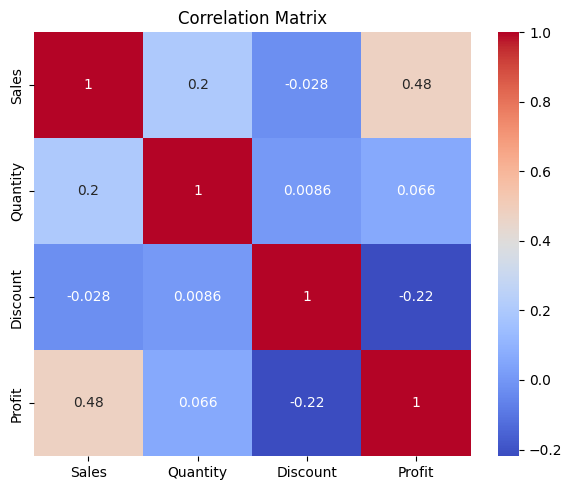

In [31]:
# CORRELATION HEATMAP
plt.figure(figsize=(6,5))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()